## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=1)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "vllm_compute_s",
]]


,end_to_end_s,server_roundtrip_s,router_queue_s,vllm_compute_s
count,200.000000,200.000000,200.000000,200.000000
mean,57.795467,56.181367,25.247258,25.497478
std,23.565479,22.952920,21.505428,23.440518
min,11.520083,11.103379,0.048732,0.491463
50%,61.875985,59.775285,24.027480,18.032927
90%,84.396536,82.213598,56.068665,62.693310
99%,112.464290,109.601380,64.114528,96.593244
max,119.024286,116.272725,64.920739,103.313918


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,serving_pod,...,applied_time_offset_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_post_result_s,server_roundtrip_s
0,36,98c124a6afae45a390cd8ca919f1c8ff,False,11.520083,11.066161,stop,381,3,384,None,...,NaN,0.416704,0.433301,0.015895,0.000116,11.067440,0.000092,0.002458,0.000765,11.103379
1,12,d088e191fdcc4c69ad5d1e13b5cb8643,False,11.842530,11.608371,stop,319,3,322,None,...,NaN,0.177175,0.211616,0.016350,0.000990,11.609356,0.000055,0.003003,0.001142,11.665354
2,7,82c1ff2cd40e4a8f9ba97da68b4bd7fb,False,11.903915,11.638632,stop,457,4,461,None,...,NaN,0.085120,0.230718,0.016350,0.014168,11.639703,0.000048,0.002461,0.000406,11.818795
3,4,31cd5d2f81ed418d9f0e41607fecda7c,False,14.100425,13.847667,stop,450,3,453,None,...,NaN,0.112029,0.228019,0.015296,0.000104,13.849318,0.000053,0.007111,0.000510,13.988396
4,33,9fd355c57efe46a78bf9cf4742e14718,False,14.043286,13.596580,stop,297,3,300,None,...,NaN,0.404413,0.422870,0.015266,0.000103,13.598464,0.000065,0.004795,0.001712,13.638873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38,c73683fb920b462783383d011ea1c5c6,False,103.935939,103.312795,length,413,2048,2461,None,...,NaN,0.464399,0.590321,0.015841,0.011887,103.313918,0.000147,0.003269,0.000547,103.471540
196,142,4cdd4cea7d2b43bdbe985033db58c39b,False,104.593334,42.861517,stop,276,1482,1758,None,...,NaN,3.253358,61.726610,0.000676,0.000038,42.862381,0.000082,0.003091,0.000450,101.339975
197,119,5a2f0cfd42c643dd9ac5131f3671781a,False,112.447543,57.699725,stop,380,1887,2267,None,...,NaN,2.863583,54.741109,0.000721,0.000050,57.700992,0.000177,0.003970,0.000518,109.583960
198,137,925121e7ea7044cd9d7862b0bfeef1ba,False,114.122233,62.404224,length,382,2048,2430,None,...,NaN,2.796322,51.712594,0.000625,0.000039,62.405280,0.000127,0.003056,0.000505,111.325910


In [3]:
from experiment_analysis import experiments_from_series, experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)

# ----------------------------------------------
# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]
percentiles = [0.5, 0.9, 0.99]
summaries = []
for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)
# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[269, 270, 271, 272, 273]


,exp269_end_to_end_s,exp270_end_to_end_s,exp271_end_to_end_s,exp272_end_to_end_s,exp273_end_to_end_s
count,128.000000,128.000000,128.000000,128.000000,128.000000
mean,27.781939,26.409037,95.862869,25.229979,65.791410
std,12.440919,12.844408,45.597962,9.890226,37.238170
min,9.149684,8.431154,36.014106,9.790232,19.493327
50%,26.581644,27.418094,94.011763,23.656780,59.177249
90%,44.708058,42.953196,146.925473,38.122496,136.256969
99%,48.861864,51.230267,200.565084,43.569379,146.830185
max,53.700201,51.483620,201.576958,45.628937,147.845341


[269, 270, 271, 272, 273]
[exp 269] corrected_requests=128/128
[exp 270] corrected_requests=0/128
[exp 271] corrected_requests=128/128
[exp 272] corrected_requests=128/128
[exp 273] corrected_requests=128/128

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 269:
  client_to_router_s          : -833.099 s
  router_queue_s              : -820.191 s
  router_to_sidecar_s         :  833.036 s
  sidecar_queue_s             :    0.004 s
  vllm_compute_s              :   14.801 s
  sidecar_post_s              :    0.000 s
  sidecar_to_router_s         : -833.011 s
  router_post_result_s        :      nan s
  SUM (components)            : -1638.459 s

  Router post-result breakdown:
    router_result_handler_s   : 0.000001 s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000001 s

  end_to_end_s                :   27.782 s

Experiment 270:
 

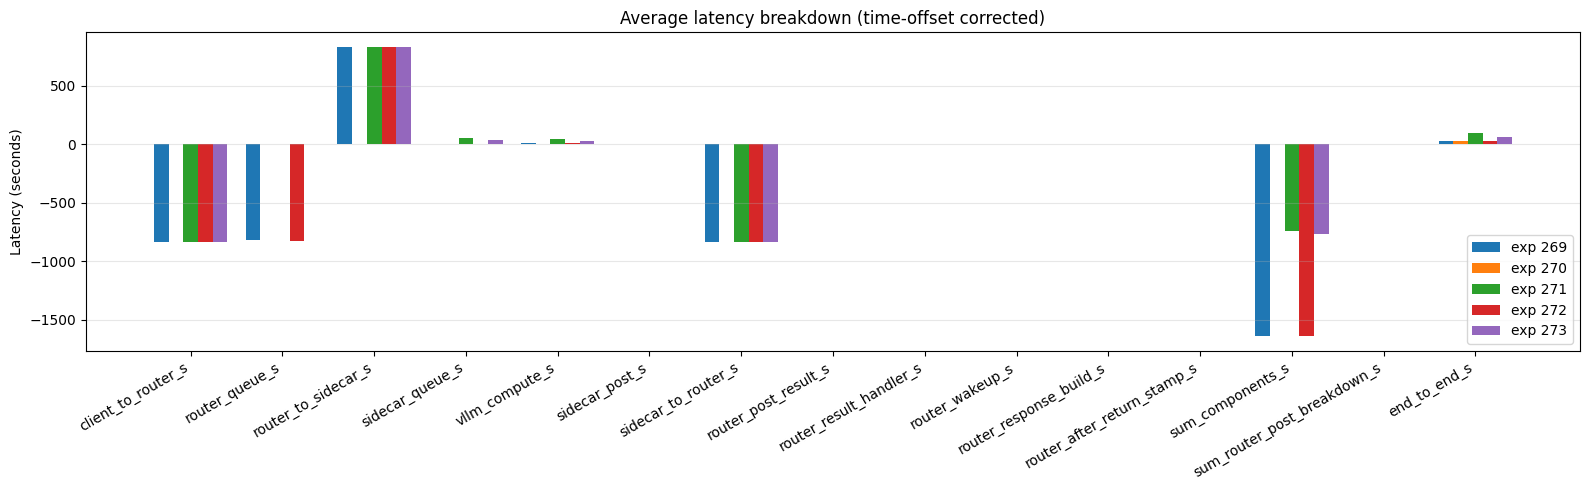

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range 
experiments = list(range(269, 274))

print(experiments)
# ---------------------------
# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================
# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]
# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]
extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]
e2e_col = "end_to_end_s"
plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)
avg_by_exp = {}
for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
    )
    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")
    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))
    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))
    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)
    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")
    row = {}
    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))
    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))
    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))
    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean
    avg_by_exp[exp_id] = row
# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")
for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")
    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")
    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()
    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")
    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()
    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()
# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))
plt.figure(figsize=(16, 5))
for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")
plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

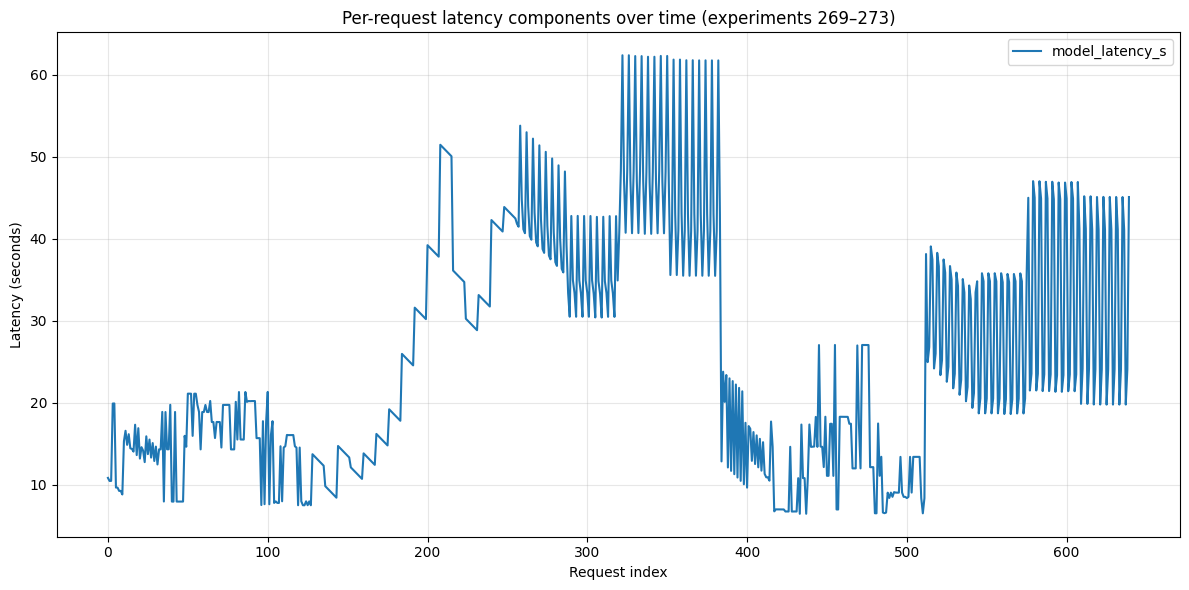

In [6]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
# Option A: single experiment
# exp_id = 1

# Option B: by start/end range
experiments = list(range(269, 274))
# ---------------------------

import pandas as pd

dfs = []
for exp_id in experiments:
    _df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)
    _df["exp_id"] = exp_id
    dfs.append(_df)
df = pd.concat(dfs, ignore_index=True)

# X-axis: request index (0, 1, 2, ...)
x = df.index

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    # "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]
plt.figure(figsize=(12, 6))
for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)
plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiments {experiments[0]}–{experiments[-1]})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[269, 270, 271, 272, 273]
[exp 269] corrected_requests=128/128
[exp 270] corrected_requests=0/128
[exp 271] corrected_requests=128/128
[exp 272] corrected_requests=128/128
[exp 273] corrected_requests=128/128


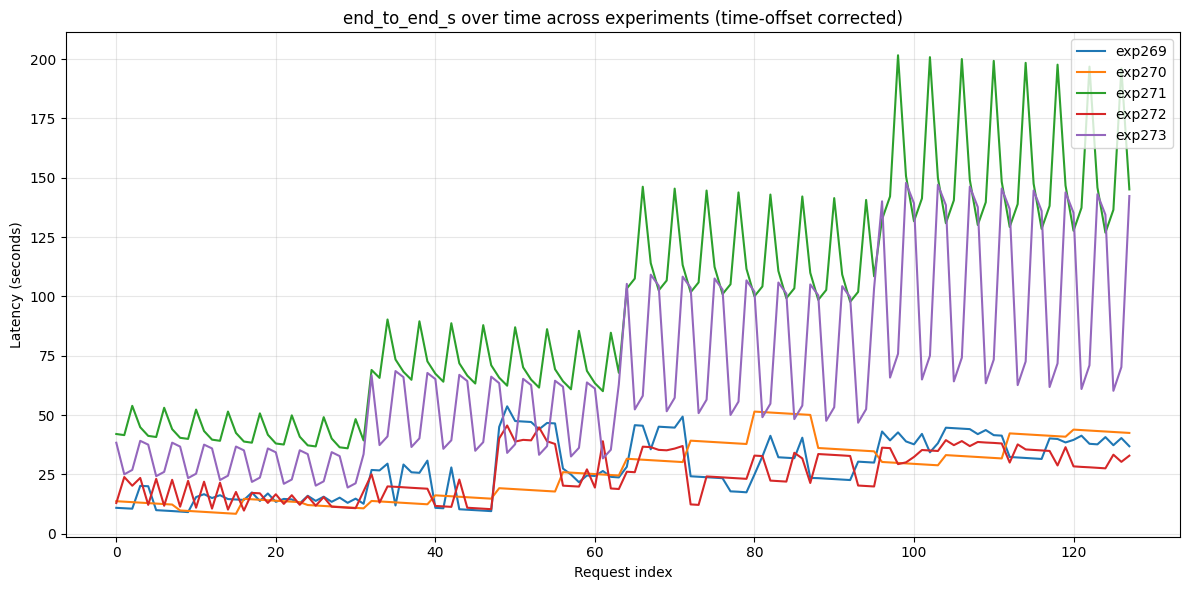

In [7]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

# experiments = [142]
print(experiments)
# ----------------------------
# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================
# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
#metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )
    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Throughput Metrics

In [8]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
# -------- choose experiments to compare --------
# choose which series you want
# Option A: by series IDs
# series_ids = [35]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    "prefill_tokens_per_sec",
    "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",

    "gpu_kv_cache_usage_frac",
    "cpu_kv_cache_usage_frac",
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[269, 270, 271, 272, 273]
[WARN] exp269: columns not found in prom, skipping: {'cpu_kv_cache_usage_frac', 'gpu_kv_cache_usage_frac'}
[WARN] exp270: columns not found in prom, skipping: {'cpu_kv_cache_usage_frac', 'gpu_kv_cache_usage_frac'}
[WARN] exp271: columns not found in prom, skipping: {'cpu_kv_cache_usage_frac', 'gpu_kv_cache_usage_frac'}
[WARN] exp272: columns not found in prom, skipping: {'cpu_kv_cache_usage_frac', 'gpu_kv_cache_usage_frac'}
[WARN] exp273: columns not found in prom, skipping: {'cpu_kv_cache_usage_frac', 'gpu_kv_cache_usage_frac'}


,exp269_gen_tokens_per_sec,exp269_prefill_tokens_per_sec,exp269_requests_running,exp269_ttft_seconds_avg,exp269_tpot_seconds_avg,exp270_gen_tokens_per_sec,exp270_prefill_tokens_per_sec,exp270_requests_running,exp270_ttft_seconds_avg,exp270_tpot_seconds_avg,exp271_gen_tokens_per_sec,exp271_prefill_tokens_per_sec,exp271_requests_running,exp271_ttft_seconds_avg,exp271_tpot_seconds_avg,exp272_gen_tokens_per_sec,exp272_prefill_tokens_per_sec,exp272_requests_running,exp272_ttft_seconds_avg,exp272_tpot_seconds_avg,exp273_gen_tokens_per_sec,exp273_prefill_tokens_per_sec,exp273_requests_running,exp273_ttft_seconds_avg,exp273_tpot_seconds_avg
count,14.000000,14.000000,14.000000,13.000000,11.000000,15.000000,15.000000,15.00000,14.000000,12.000000,45.000000,45.000000,45.000000,40.000000,32.000000,12.000000,12.000000,12.000000,11.000000,9.000000,34.000000,34.000000,34.000000,33.000000,26.000000
mean,6.258193,671.355759,3.785714,11.082373,0.581799,5.939270,633.004084,1.00000,16.143799,0.120440,2.595448,274.785492,2.866667,29.298463,1.313345,5.942682,645.418227,4.583333,9.435717,0.743961,3.236148,348.206572,4.117647,22.367995,1.429639
std,4.198868,428.726360,3.142233,4.764368,0.176329,3.499990,370.739294,2.13809,10.123950,0.079207,1.938301,192.746880,1.726794,12.077243,0.267112,4.660775,478.816383,4.252450,4.141727,0.297004,2.371213,219.736227,2.694154,10.849054,0.582648
min,0.000000,0.000000,0.000000,1.869643,0.422392,0.000000,0.000000,0.00000,2.159411,0.028599,0.000000,0.000000,0.000000,6.775688,0.935782,0.000000,0.000000,0.000000,2.027136,0.307370,0.000000,0.000000,0.000000,3.859651,0.682723
50%,6.916297,750.569923,3.000000,11.290714,0.570387,7.724138,787.717678,0.00000,12.510646,0.141212,2.724138,323.551724,3.000000,31.036997,1.239264,7.615350,775.992339,3.000000,10.173453,0.882755,2.775801,315.086486,4.000000,23.597798,1.252637
90%,10.840077,1139.158621,7.400000,16.114184,0.633303,8.956271,961.103448,2.60000,31.534127,0.215032,5.200000,511.531034,5.000000,41.569121,1.648012,10.713793,1124.968966,10.900000,12.382934,0.995630,6.448276,640.848276,6.700000,38.180700,2.360600
99%,11.432489,1202.961379,11.480000,16.223871,1.012912,8.975985,969.379310,7.30000,32.579316,0.220040,5.517241,599.103448,6.000000,46.375611,1.867215,12.005172,1275.960651,12.780000,15.173864,1.001989,7.692823,684.278719,12.350000,44.278401,2.416197
max,11.517241,1209.793103,12.000000,16.225143,1.055091,8.978805,969.379310,8.00000,32.623742,0.220648,5.517241,599.103448,6.000000,46.375611,1.887763,12.159240,1294.524947,13.000000,15.483967,1.002695,7.716690,687.243842,14.000000,45.514712,2.421037
SLO_COMPLIANCE_%,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,33.333333,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000


[269, 270, 271, 272, 273]


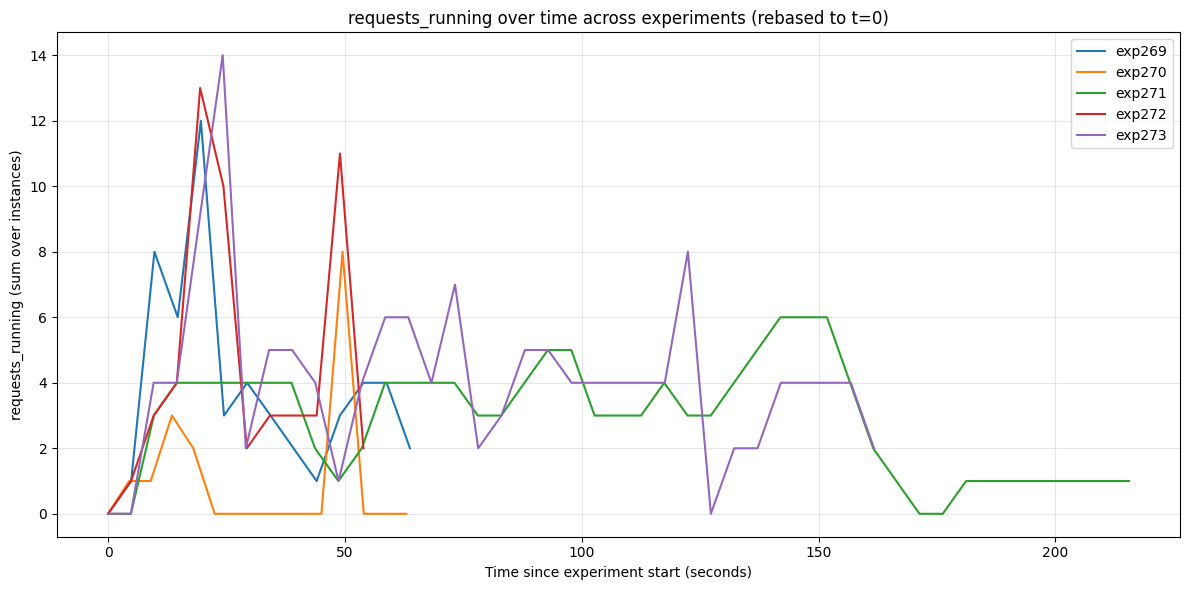

In [9]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# -----------------------------------------------
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()
    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"
    x = series.index
    y = series.values
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Token Length Distribution

[269, 270, 271, 272, 273]


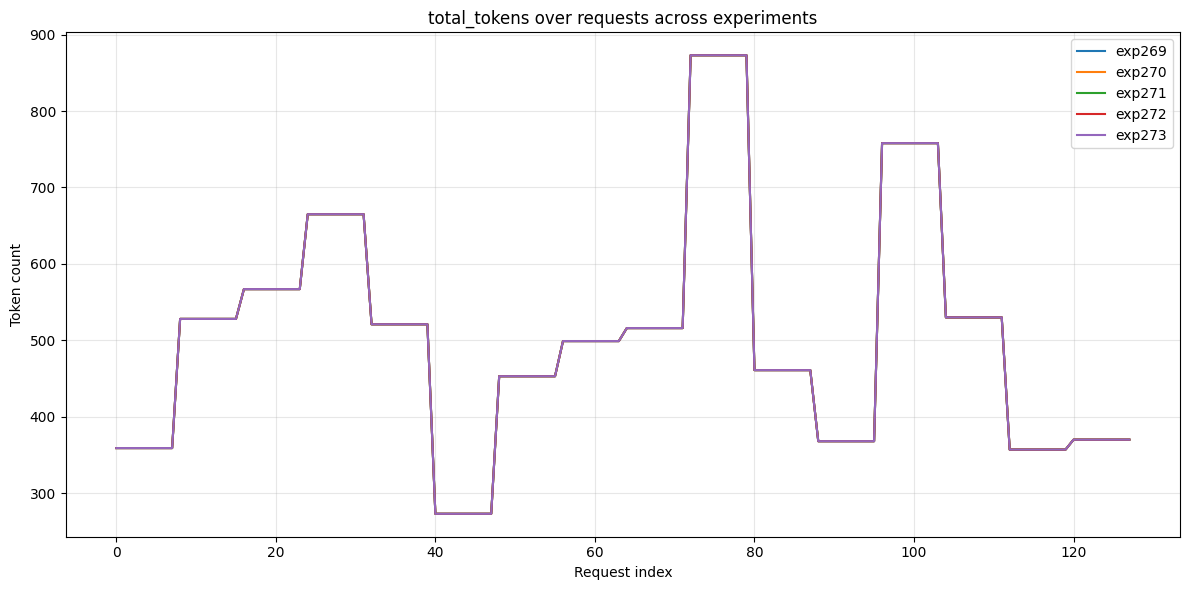

In [10]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[269, 270, 271, 272, 273]


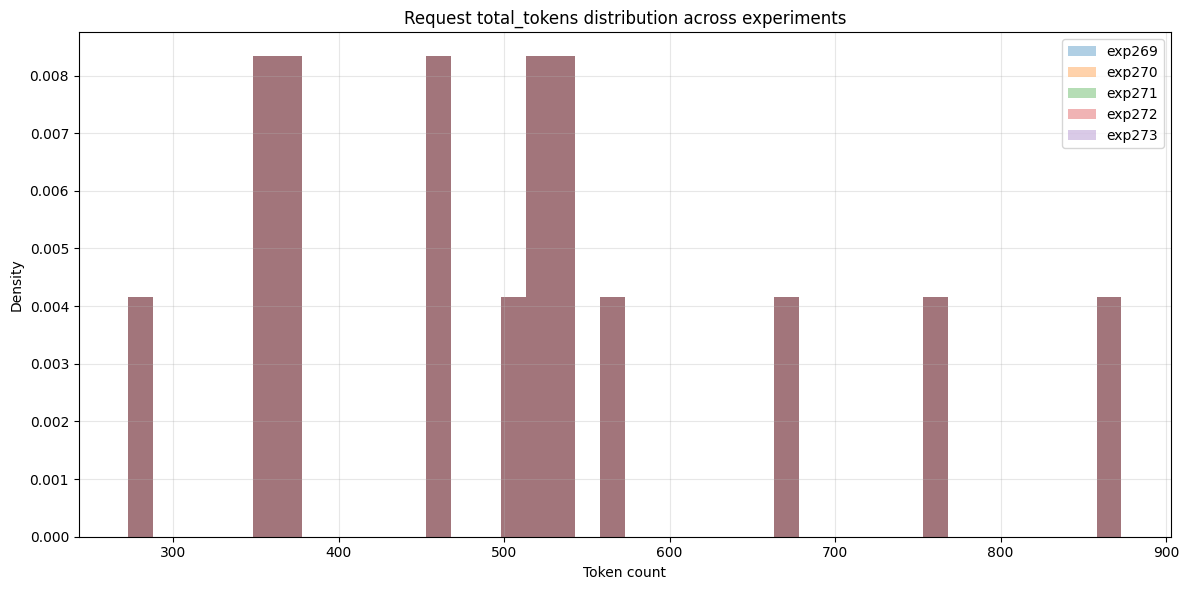

In [11]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue
    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )
plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [12]:
from pathlib import Path
from experiment_analysis import experiments_from_series
import json
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------
def count_requests(exp_id, experiments_root="experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"
    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")
    total = 0
    success = 0
    send_failed = 0
    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1
            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1
    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }
rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))
df_counts = pd.DataFrame(rows)
df_counts

[269, 270, 271, 272, 273]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,269,128,128,0,100.0,0.0
1,270,128,128,0,100.0,0.0
2,271,128,128,0,100.0,0.0
3,272,128,128,0,100.0,0.0
4,273,128,128,0,100.0,0.0


In [13]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import pandas as pd

# -------- choose experiments to compare --------
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------------------------
percentiles = [0.5, 0.9, 0.99]
# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================
METRICS_MODE = "all_new"  # <- change me
ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]
SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]
MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}
if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")
SELECT_COLS = MODE_TO_COLS[METRICS_MODE]
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None
    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)
    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None
    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)
    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")
summaries = []
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue
    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)
    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)
    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)
    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)
        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)
comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison

[269, 270, 271, 272, 273]
[WARN] exp270: no router (:8080) samples found
[WARN] exp270: no vLLM (:8200) samples found for sidecar_*


,exp269_router_queue_length,exp269_router_admission_rps,exp269_router_outgoing_rps,exp269_sidecar_queue_length,exp269_sidecar_received_rps,exp269_sidecar_completed_rps,exp271_router_queue_length,exp271_router_admission_rps,exp271_router_outgoing_rps,exp271_sidecar_queue_length,exp271_sidecar_received_rps,exp271_sidecar_completed_rps,exp272_router_queue_length,exp272_router_admission_rps,exp272_router_outgoing_rps,exp272_sidecar_queue_length,exp272_sidecar_received_rps,exp272_sidecar_completed_rps,exp273_router_queue_length,exp273_router_admission_rps,exp273_router_outgoing_rps,exp273_sidecar_queue_length,exp273_sidecar_received_rps,exp273_sidecar_completed_rps
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,45.0,45.000000,45.000000,45.000000,45.000000,45.000000,12.00000,12.000000,12.000000,12.0000,12.000000,12.000000,34.0,34.000000,34.000000,34.000000,34.000000,34.000000
mean,24.000000,1.850667,0.331259,27.714286,1.571078,0.871036,0.0,0.582115,0.147139,55.888889,0.573893,0.392337,25.25000,2.154147,0.662232,29.0000,1.715560,0.766793,0.0,0.763228,0.193663,50.529412,0.765911,0.478317
std,20.015379,1.534321,0.149356,9.730433,0.573341,0.870806,0.0,1.225499,0.308319,39.462999,1.202637,0.399119,19.07938,1.428687,0.271796,7.0582,0.687359,0.797513,0.0,1.338074,0.335288,34.885297,1.346113,0.426302
min,0.000000,0.000000,0.043317,0.000000,0.242833,0.000000,0.0,0.000000,0.000000,8.000000,0.000000,0.000000,0.00000,0.000000,0.257347,12.0000,0.370467,0.000000,0.0,0.000000,0.000000,8.000000,0.000000,0.000000
50%,23.500000,1.724138,0.275862,32.000000,1.793103,0.565584,0.0,0.000000,0.000000,56.000000,0.000000,0.275862,27.50000,2.108452,0.821721,32.0000,1.931034,0.573578,0.0,0.000000,0.000000,38.000000,0.000000,0.551724
90%,51.500000,3.823331,0.533614,32.000000,2.132749,2.041379,0.0,2.699393,0.669451,106.400000,2.624338,0.827586,47.20000,3.814432,0.827586,32.0000,2.462268,1.878073,0.0,2.984999,0.752472,105.100000,3.076051,1.103448
99%,56.000000,4.262557,0.551724,32.000000,2.214898,2.446897,0.0,4.191080,1.058410,128.000000,4.133133,1.103448,48.89000,4.256988,1.053379,32.0000,2.546989,2.176743,0.0,4.179972,1.047826,117.360000,4.199079,1.379310
max,56.000000,4.326253,0.551724,32.000000,2.219460,2.482759,0.0,4.395402,1.104304,128.000000,4.264830,1.103448,49.00000,4.311393,1.081286,32.0000,2.554928,2.206897,0.0,4.336552,1.088367,120.000000,4.297133,1.379310


[269, 270, 271, 272, 273]
Skipping exp270: no rows for view='router'


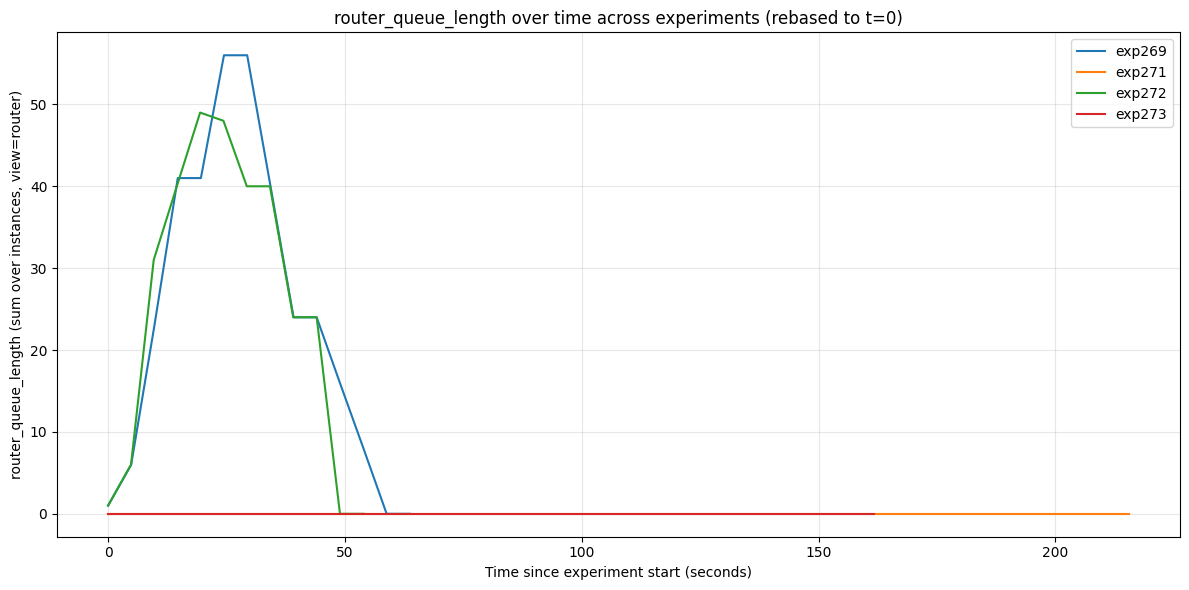

In [14]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ----------------------------
# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================
# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")
if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"
if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)
    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue
    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()
    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")
    x = series.index
    y = series.values
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[269, 270, 271, 272, 273]


/tmp/ipykernel_3771363/3127100041.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


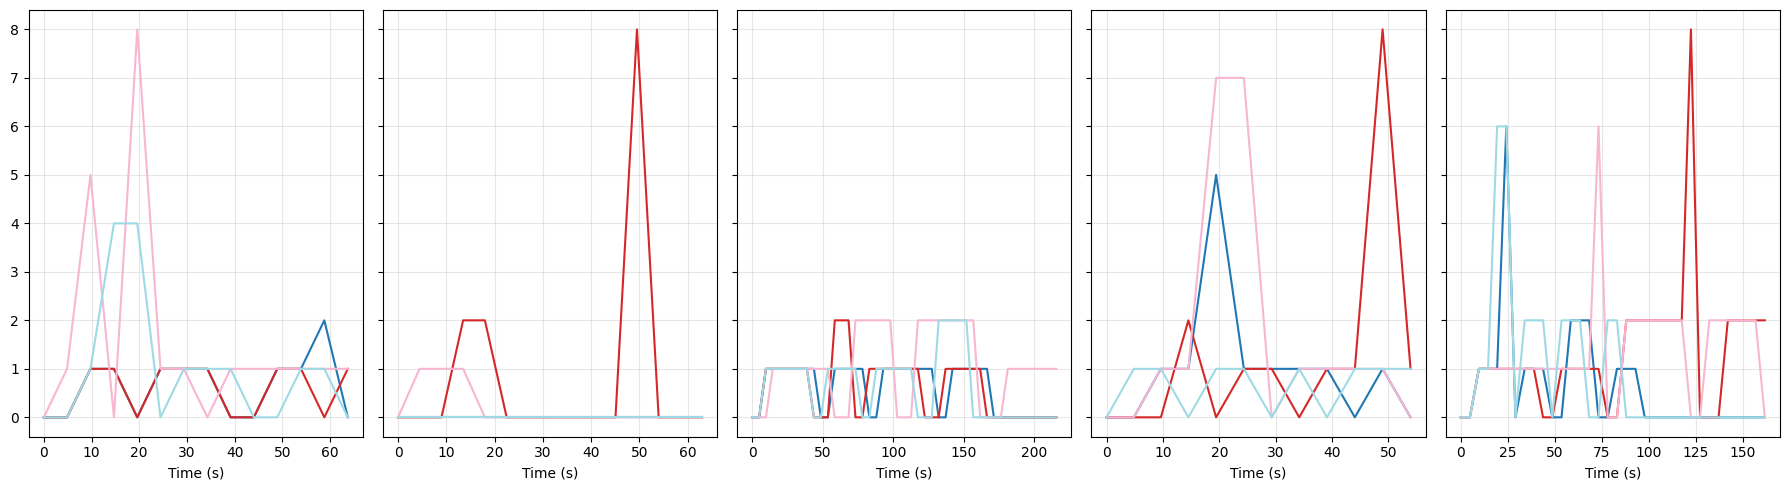

In [15]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(269, 274))

print(experiments)
# ============================================================
# Choose ONE metric
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
view = "vllm"  # sidecar_* live on vLLM (:8200)
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]
# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)
    if df.empty or metric not in df.columns:
        continue
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()
    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}
    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)
    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))
# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]
# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}
# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]
for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue
    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)
plt.show()